# Random Forest pour l'orientation des patients

Ce notebook construit un pipeline complet d'orientation des patients vers l'hôpital le plus adapte.

Le flux global est le suivant :
1. charger et nettoyer les donnees patients/hopitaux,
2. verifier la faisabilite (ressources suffisantes),
3. creer des features patient-hopital,
4. entrainer un modele Random Forest,
5. utiliser le modele pour allouer les patients,
6. gerer un buffer (file d'attente) si aucune allocation immediate n'est possible.

In [2]:
import pandas as pd
import numpy as np
import heapq
import time
import copy
import shutil
import tempfile
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## 1) Mapping des ressources

Cette section definit une table de correspondance entre :
- les colonnes des besoins patients (`p`),
- et les colonnes des capacites hopital (`h`).

Ce mapping permet de comparer automatiquement les besoins d'un patient et les ressources disponibles dans chaque hopital, de maniere uniforme pour toutes les ressources.

In [3]:
RESOURCE_MAPPINGS = {
    'Lit': {'p': 'Lits_totaux', 'h': 'Lits totaux'},
    'Rea_Lit': {'p': 'Rea_lits', 'h': 'Réa (lits)'},
    'Medecin': {'p': 'Medecins', 'h': 'Médecins'},
    'Infirmier': {'p': 'Infirmiers', 'h': 'Infirmiers'},
    'Urgentiste': {'p': 'Urgentistes', 'h': 'Urgentistes'},
    'Reanimateur': {'p': 'Reanimateurs', 'h': 'Réanimateurs'},
    'Anesth_Rea': {'p': 'Anesth_Rea', 'h': 'Anesth.-Réa'},
    'Pneumo': {'p': 'Pneumo', 'h': 'Pneumo'},
    'Cardio': {'p': 'Cardio', 'h': 'Cardio'},
    'Neuro': {'p': 'Neuro', 'h': 'Neuro'},
    'Interniste': {'p': 'Internistes', 'h': 'Internistes'},
    'Chirurgien': {'p': 'Chirurgiens', 'h': 'Chirurgiens'},
    'Pediatre': {'p': 'Pediatres', 'h': 'Pédiatres'},
    'Biologiste': {'p': 'Biologistes', 'h': 'Biologistes'},
    'Radiologue': {'p': 'Radiologues', 'h': 'Radiologues'},
    'O2': {'p': 'O2', 'h': 'O₂'},
    'Ventilateur': {'p': 'Ventilateur', 'h': 'Ventilateurs'},
    'Sang': {'p': 'Sang', 'h': 'Sang (unités)'},
    'Moniteur': {'p': 'Moniteurs', 'h': 'Moniteurs'},
    'Defibrillateur': {'p': 'Defibrillateur', 'h': 'Défibrillateurs'},
    'Monitoring': {'p': 'Monitoring', 'h': 'Moniteurs'},
    'Labo': {'p': 'Labo', 'h': 'Labo'},
    'Imagerie': {'p': 'Imagerie', 'h': 'Imagerie'}
}

In [ ]:
RESOURCE_MAPPINGS

{'Lit': {'p': 'Lits_totaux', 'h': 'Lits totaux'},
 'Rea_Lit': {'p': 'Rea_lits', 'h': 'Réa (lits)'},
 'Medecin': {'p': 'Medecins', 'h': 'Médecins'},
 'Infirmier': {'p': 'Infirmiers', 'h': 'Infirmiers'},
 'Urgentiste': {'p': 'Urgentistes', 'h': 'Urgentistes'},
 'Reanimateur': {'p': 'Reanimateurs', 'h': 'Réanimateurs'},
 'Anesth_Rea': {'p': 'Anesth_Rea', 'h': 'Anesth.-Réa'},
 'Pneumo': {'p': 'Pneumo', 'h': 'Pneumo'},
 'Cardio': {'p': 'Cardio', 'h': 'Cardio'},
 'Neuro': {'p': 'Neuro', 'h': 'Neuro'},
 'Interniste': {'p': 'Internistes', 'h': 'Internistes'},
 'Chirurgien': {'p': 'Chirurgiens', 'h': 'Chirurgiens'},
 'Pediatre': {'p': 'Pediatres', 'h': 'Pédiatres'},
 'Biologiste': {'p': 'Biologistes', 'h': 'Biologistes'},
 'Radiologue': {'p': 'Radiologues', 'h': 'Radiologues'},
 'O2': {'p': 'O2', 'h': 'O₂'},
 'Ventilateur': {'p': 'Ventilateur', 'h': 'Ventilateurs'},
 'Sang': {'p': 'Sang', 'h': 'Sang (unités)'},
 'Moniteur': {'p': 'Moniteurs', 'h': 'Moniteurs'},
 'Defibrillateur': {'p': 'Defibri

## 2) Chargement et nettoyage des donnees

Les donnees sont lues depuis deux fichiers Excel :
- un fichier hopitaux (capacites),
- un fichier patients (besoins + localisation + gravite).

Les colonnes de ressources cote hopitaux sont converties en numerique et les valeurs manquantes sont remplacees par 0 pour eviter les erreurs de calcul.

In [4]:
PROJECT_DIR = Path.cwd()
DATA_CANDIDATE_DIRS = [
    PROJECT_DIR,
    Path(r"c:\Users\HP\OneDrive\Desktop\silma\ml_model_for_patients_orientation"),
]


def resolve_data_file(filename):
    for folder in DATA_CANDIDATE_DIRS:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    return PROJECT_DIR / filename


def safe_read_excel(path, retries=5, wait_seconds=0.6):
    file_path = Path(path)
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            return pd.read_excel(file_path)
        except PermissionError as exc:
            last_error = exc
            print(f"[Tentative {attempt}/{retries}] Fichier verrouille: {file_path.name}")
            if attempt < retries:
                time.sleep(wait_seconds)

    raise PermissionError(f"Impossible de lire '{file_path.name}' apres {retries} tentatives.") from last_error


def try_read_via_temp_copy(path):
    src = Path(path)
    tmp_dir = Path(tempfile.gettempdir())
    tmp_file = tmp_dir / f"tmp_{src.stem}_{int(time.time())}{src.suffix}"

    try:
        shutil.copy2(src, tmp_file)
        return pd.read_excel(tmp_file)
    finally:
        if tmp_file.exists():
            try:
                tmp_file.unlink()
            except OSError:
                pass


def load_with_cache(excel_name, cache_name):
    excel_path = resolve_data_file(excel_name)
    cache_path = resolve_data_file(cache_name)

    if cache_path.exists():
        try:
            return pd.read_pickle(cache_path)
        except Exception:
            pass

    try:
        df = safe_read_excel(excel_path)
        df.to_pickle(cache_path)
        return df
    except PermissionError:
        pass

    try:
        df = try_read_via_temp_copy(excel_path)
        df.to_pickle(cache_path)
        print(f"Lecture via copie temporaire: {excel_path.name}")
        return df
    except Exception:
        pass

    if cache_path.exists():
        print(f"Lecture depuis cache: {cache_path.name}")
        return pd.read_pickle(cache_path)

    raise PermissionError(
        f"Acces refuse a '{excel_path.name}'. Ferme Excel + apercu IDE, ou cree une copie locale hors OneDrive."
    )


hospitals_df = load_with_cache("Book1.xlsx", "Book1_cache.pkl")
patients_df = load_with_cache("patients_1000_ULTRA_COMPLET.xlsx", "patients_cache.pkl")

resource_cols_h = [mapping["h"] for mapping in RESOURCE_MAPPINGS.values()]
for col in resource_cols_h:
    hospitals_df[col] = pd.to_numeric(hospitals_df[col], errors="coerce").fillna(0)

hospitals = hospitals_df.to_dict(orient="records")
patients = patients_df.to_dict(orient="records")

## 3) Verification de faisabilite

La fonction `hospital_can_handle` verifie si un hopital peut prendre en charge un patient.

Principe : pour chaque ressource du mapping, on compare `capacite_hopital >= besoin_patient`.
Si une seule ressource est insuffisante, la prise en charge est consideree impossible.

In [5]:
def hospital_can_handle(patient, hospital):
    for res, keys in RESOURCE_MAPPINGS.items():
        p_val = patient.get(keys['p'], 0)
        h_val = hospital.get(keys['h'], 0)

        if pd.isna(p_val): p_val = 0
        if pd.isna(h_val): h_val = 0

        if h_val < p_val:
            return False

    return True

## 4) Feature engineering

La fonction `create_features` fabrique les variables d'entree du modele pour un couple (patient, hopital) :
- ecart de ressources (`diff`),
- ratio de ressources (`ratio`),
- niveau de gravite `ESI`,
- distance geographique patient-hopital.

Ces features permettent au modele de scorer la pertinence de chaque hopital pour un patient donne.

In [6]:
def create_features(patient, hospital):
    features = {}

    for res, keys in RESOURCE_MAPPINGS.items():
        p_val = patient.get(keys['p'], 0)
        h_val = hospital.get(keys['h'], 0)

        if pd.isna(p_val): p_val = 0
        if pd.isna(h_val): h_val = 0

        features[f"{res}_diff"] = h_val - p_val
        features[f"{res}_ratio"] = (h_val + 1) / (p_val + 1)

    features["ESI"] = patient["ESI"]

    # Distance
    features["distance"] = (
        (patient["Latitude"] - hospital["Lat"])**2 +
        (patient["Longitude"] - hospital["Long"])**2
    ) ** 0.5

    return features

## 5) Construction du pseudo ground truth

La fonction `create_label` cree une cible binaire d'apprentissage :
- `0` si l'hopital ne peut pas traiter le patient,
- sinon `1` uniquement pour l'hopital valide le plus proche,
- `0` pour les autres hopitaux.

Important : il s'agit d'un *pseudo* ground truth base sur une regle (capacite + proximite), pas sur des decisions medicales historiques reelles.

In [7]:
def create_label(patient, hospital, hospitals):
    if not hospital_can_handle(patient, hospital):
        return 0

    valid = [h for h in hospitals if hospital_can_handle(patient, h)]

    if not valid:
        return 0

    best = min(valid, key=lambda h: (
        (patient["Latitude"] - h["Lat"])**2 +
        (patient["Longitude"] - h["Long"])**2
    ))

    return 1 if hospital["Hôpital"] == best["Hôpital"] else 0

## 6) Construction du dataset d'entrainement

Le notebook genere tous les couples possibles (patient, hopital).

Pour chaque couple :
- on calcule les features,
- on calcule le label,
- on ajoute le resultat dans `X` (entrees) et `y` (cibles).

In [8]:
# Safety check: auto-restore data even if cells were executed out of order.
if "patients" not in globals() or "hospitals" not in globals():
    if "patients_df" in globals() and "hospitals_df" in globals():
        patients = patients_df.to_dict(orient="records")
        hospitals = hospitals_df.to_dict(orient="records")
    else:
        if "load_with_cache" in globals():
            hospitals_df = load_with_cache("Book1.xlsx", "Book1_cache.pkl")
            patients_df = load_with_cache("patients_1000_ULTRA_COMPLET.xlsx", "patients_cache.pkl")
        else:
            hospitals_df = pd.read_excel("Book1.xlsx")
            patients_df = pd.read_excel("patients_1000_ULTRA_COMPLET.xlsx")

        resource_cols_h = [mapping["h"] for mapping in RESOURCE_MAPPINGS.values()]
        for col in resource_cols_h:
            hospitals_df[col] = pd.to_numeric(hospitals_df[col], errors="coerce").fillna(0)

        hospitals = hospitals_df.to_dict(orient="records")
        patients = patients_df.to_dict(orient="records")

X = []
y = []

for patient in patients:
    for hospital in hospitals:
        features = create_features(patient, hospital)
        label = create_label(patient, hospital, hospitals)

        X.append(list(features.values()))
        y.append(label)

if len(X) == 0:
    raise ValueError("Dataset vide: impossible d'entrainer le modele. Verifie le chargement des donnees.")

## 7) Entrainement du modele

Les donnees sont separees en train/test (`80/20`), puis un `RandomForestClassifier` est entraine.

Hyperparametres utilises :
- `n_estimators=100` (nombre d'arbres),
- `max_depth=12` (profondeur maximale),
- `random_state=42` (reproductibilite).

In [9]:
if "X" not in globals() or len(X) == 0:
    raise ValueError("X est vide/non defini. Execute d'abord la cellule de construction du dataset.")

if len(set(y)) < 2:
    raise ValueError("La cible y ne contient qu'une seule classe. Verifie les donnees/labels.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=14,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 8) Evaluation du modele

Le modele est evalue avec plusieurs metriques :
- Accuracy,
- Precision,
- Recall,
- F1-score.

Cette combinaison permet d'avoir une vision plus fiable que l'accuracy seule, surtout en cas de classes desequilibrees.

In [10]:
if "model" not in globals():
    raise ValueError("Modele non entraine. Execute d'abord la cellule d'entrainement.")

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))

Accuracy: 0.9647727272727272
Precision: 0.5991189427312775
Recall: 0.68
F1-score: 0.6370023419203747


## 9) Moteur operationnel continu

A partir d'ici, on passe a une logique de simulation evenementielle :
- `ARRIVAL` : arrivee d'un patient,
- `DISCHARGE` : liberation des ressources apres prise en charge.

Le buffer suit la priorite clinique :
1. `ESI` (1 est le plus prioritaire),
2. puis FIFO via l'instant d'entree en attente.

In [11]:
class PatientQueue:
    def __init__(self):
        self.queue = []
        self.counter = 0

    def add_patient(self, patient, current_time):
        item = dict(patient)
        item.setdefault("waiting_since", current_time)
        priority = (item["ESI"], item["waiting_since"], self.counter)
        heapq.heappush(self.queue, (priority, item))
        self.counter += 1

    def get_next_patient(self):
        if self.queue:
            return heapq.heappop(self.queue)[1]
        return None

    def __len__(self):
        return len(self.queue)

## 10) Allocation dynamique et mise a jour des ressources

Lorsqu'un patient est alloue :
- on choisit le meilleur hopital faisable via le score du modele,
- on decremente immediatement les ressources consommees,
- on planifie un evenement de sortie (`DISCHARGE`) qui re-liberera les ressources.

Si aucun hopital n'est faisable, le patient est envoye dans le buffer.

In [12]:
def initialize_hospital_state(hospitals):
    return [copy.deepcopy(h) for h in hospitals]


def consume_resources(patient, hospital):
    for _, keys in RESOURCE_MAPPINGS.items():
        p_val = patient.get(keys["p"], 0)
        if pd.isna(p_val):
            p_val = 0
        hospital[keys["h"]] = hospital.get(keys["h"], 0) - p_val


def release_resources(patient, hospital):
    for _, keys in RESOURCE_MAPPINGS.items():
        p_val = patient.get(keys["p"], 0)
        if pd.isna(p_val):
            p_val = 0
        hospital[keys["h"]] = hospital.get(keys["h"], 0) + p_val


def estimate_stay_duration(patient):
    # Plus ESI est critique, plus la duree de prise en charge est longue.
    duration_map = {1: 12, 2: 9, 3: 6, 4: 4, 5: 3}
    return duration_map.get(int(patient.get("ESI", 3)), 6)


def allocate_patient_dynamic(patient, hospitals_state, model):
    valid_hospitals = [h for h in hospitals_state if hospital_can_handle(patient, h)]

    if not valid_hospitals:
        return "BUFFER", None

    scored = []
    for h in valid_hospitals:
        features = create_features(patient, h)
        score = model.predict_proba([list(features.values())])[0][1]
        distance = features["distance"]
        scored.append((score, -distance, h))

    # score max, puis distance min via -distance
    scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
    best_hospital = scored[0][2]

    consume_resources(patient, best_hospital)
    return best_hospital, scored[0][0]

## 11) Reallocation declenchee par liberation de ressources

A chaque evenement `DISCHARGE`, on tente de reinjecter les patients du buffer.

La reinjection respecte :
- priorite ESI,
- FIFO pour ESI egal,
- allocation uniquement si les ressources sont redevenues suffisantes.

In [13]:
def attempt_reallocation_from_buffer(buffer, hospitals_state, model, current_time, events, event_counter, stats):
    pending = []

    while len(buffer) > 0:
        patient = buffer.get_next_patient()
        result, score = allocate_patient_dynamic(patient, hospitals_state, model)

        if result == "BUFFER":
            pending.append(patient)
            continue

        waiting_time = current_time - patient.get("waiting_since", current_time)
        stats["reallocated_from_buffer"] += 1
        stats["waiting_times"].append(waiting_time)
        stats["by_hospital"][result["Hôpital"]] = stats["by_hospital"].get(result["Hôpital"], 0) + 1

        stay = estimate_stay_duration(patient)
        discharge_event = {
            "event": "DISCHARGE",
            "time": current_time + stay,
            "patient": patient,
            "hospital_name": result["Hôpital"],
            "score": score,
        }
        heapq.heappush(events, (discharge_event["time"], event_counter["value"], discharge_event))
        event_counter["value"] += 1

    for p in pending:
        buffer.add_patient(p, p.get("waiting_since", current_time))


def run_operational_simulation(patients, hospitals, model):
    hospitals_state = initialize_hospital_state(hospitals)
    hospitals_by_name = {h["Hôpital"]: h for h in hospitals_state}

    events = []
    event_counter = {"value": 0}
    buffer = PatientQueue()

    stats = {
        "allocated_immediately": 0,
        "buffered": 0,
        "critical_buffered": 0,
        "reallocated_from_buffer": 0,
        "waiting_times": [],
        "by_hospital": {},
        "timeline": [],
    }

    for i, patient in enumerate(patients):
        event = {
            "event": "ARRIVAL",
            "time": float(patient.get("arrival_time", i)),
            "patient": dict(patient),
        }
        heapq.heappush(events, (event["time"], event_counter["value"], event))
        event_counter["value"] += 1

    initial_beds = {h["Hôpital"]: h.get("Lits totaux", 0) for h in hospitals_state}

    while events:
        current_time, _, ev = heapq.heappop(events)
        event_type = ev["event"]

        if event_type == "ARRIVAL":
            patient = ev["patient"]
            result, score = allocate_patient_dynamic(patient, hospitals_state, model)

            if result == "BUFFER":
                stats["buffered"] += 1
                if int(patient.get("ESI", 5)) == 1:
                    stats["critical_buffered"] += 1
                patient["waiting_since"] = current_time
                buffer.add_patient(patient, current_time)
            else:
                stats["allocated_immediately"] += 1
                stats["by_hospital"][result["Hôpital"]] = stats["by_hospital"].get(result["Hôpital"], 0) + 1
                stay = estimate_stay_duration(patient)
                discharge_event = {
                    "event": "DISCHARGE",
                    "time": current_time + stay,
                    "patient": patient,
                    "hospital_name": result["Hôpital"],
                    "score": score,
                }
                heapq.heappush(events, (discharge_event["time"], event_counter["value"], discharge_event))
                event_counter["value"] += 1

        elif event_type == "DISCHARGE":
            patient = ev["patient"]
            hospital_name = ev["hospital_name"]
            release_resources(patient, hospitals_by_name[hospital_name])

            # Reinjection immediately after resource release.
            attempt_reallocation_from_buffer(
                buffer, hospitals_state, model, current_time, events, event_counter, stats
            )

        total_current_beds = sum(h.get("Lits totaux", 0) for h in hospitals_state)
        total_initial_beds = sum(initial_beds.values()) + 1e-9
        occupancy = 1 - (total_current_beds / total_initial_beds)

        stats["timeline"].append({
            "time": current_time,
            "buffer_size": len(buffer),
            "bed_occupancy": max(0.0, min(1.0, occupancy)),
        })

    return stats

## 12) Evaluation globale + visualisation

Cette section execute la simulation complete puis affiche :
- indicateurs operationnels,
- graphes d'allocation,
- evolution temporelle du buffer,
- taux d'occupation des lits,
- distribution des temps d'attente en buffer.

Taux d'allocation final : 1.0
Taux de mise en buffer initiale : 0.164
Patients critiques initialement bufferises : 0.023
Nombre de reinjections reussies : 164
Temps d'attente moyen (unites temporelles) : 0.99


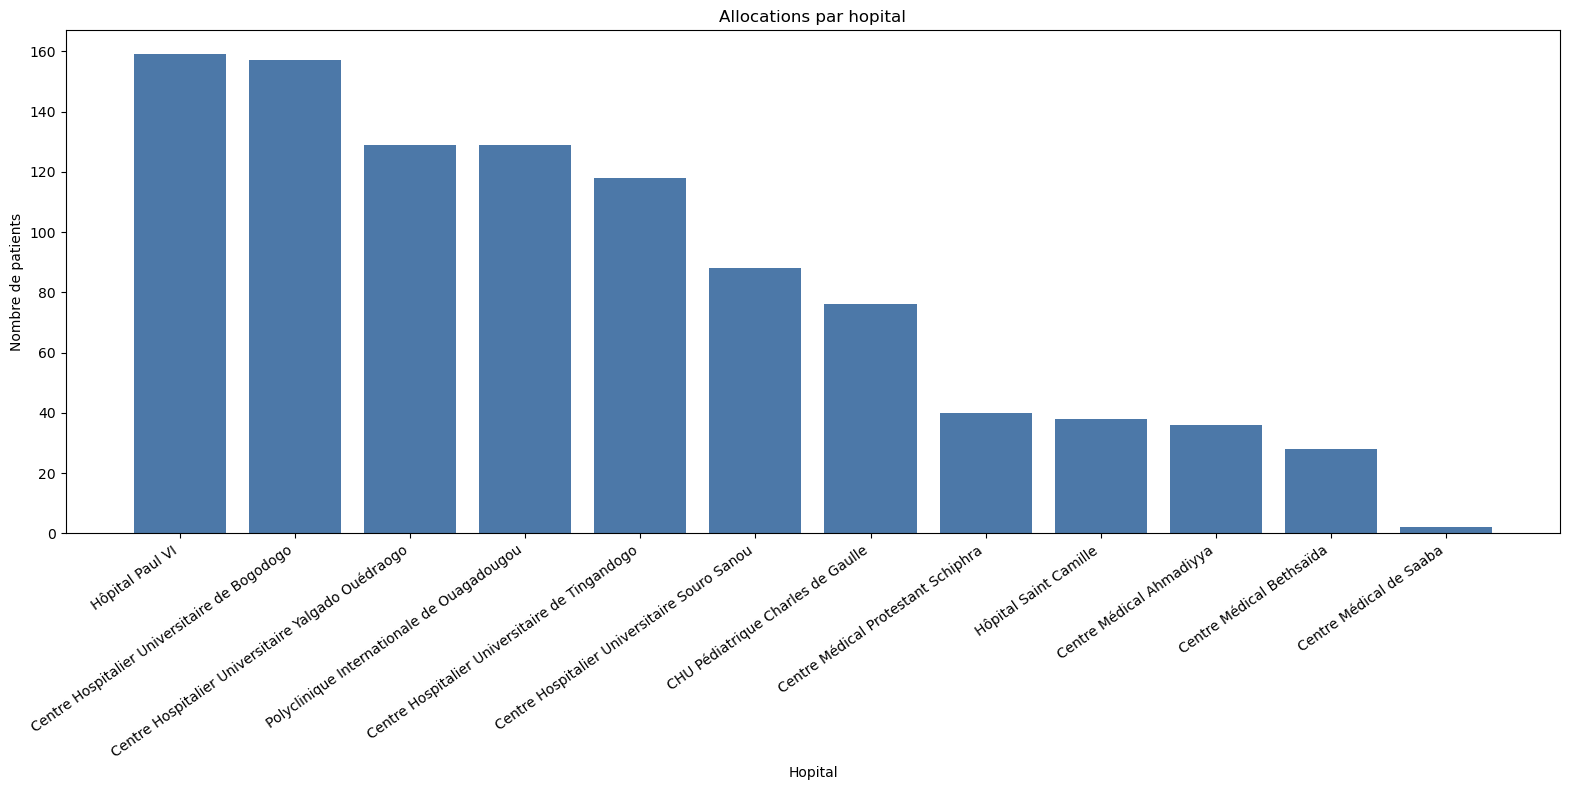

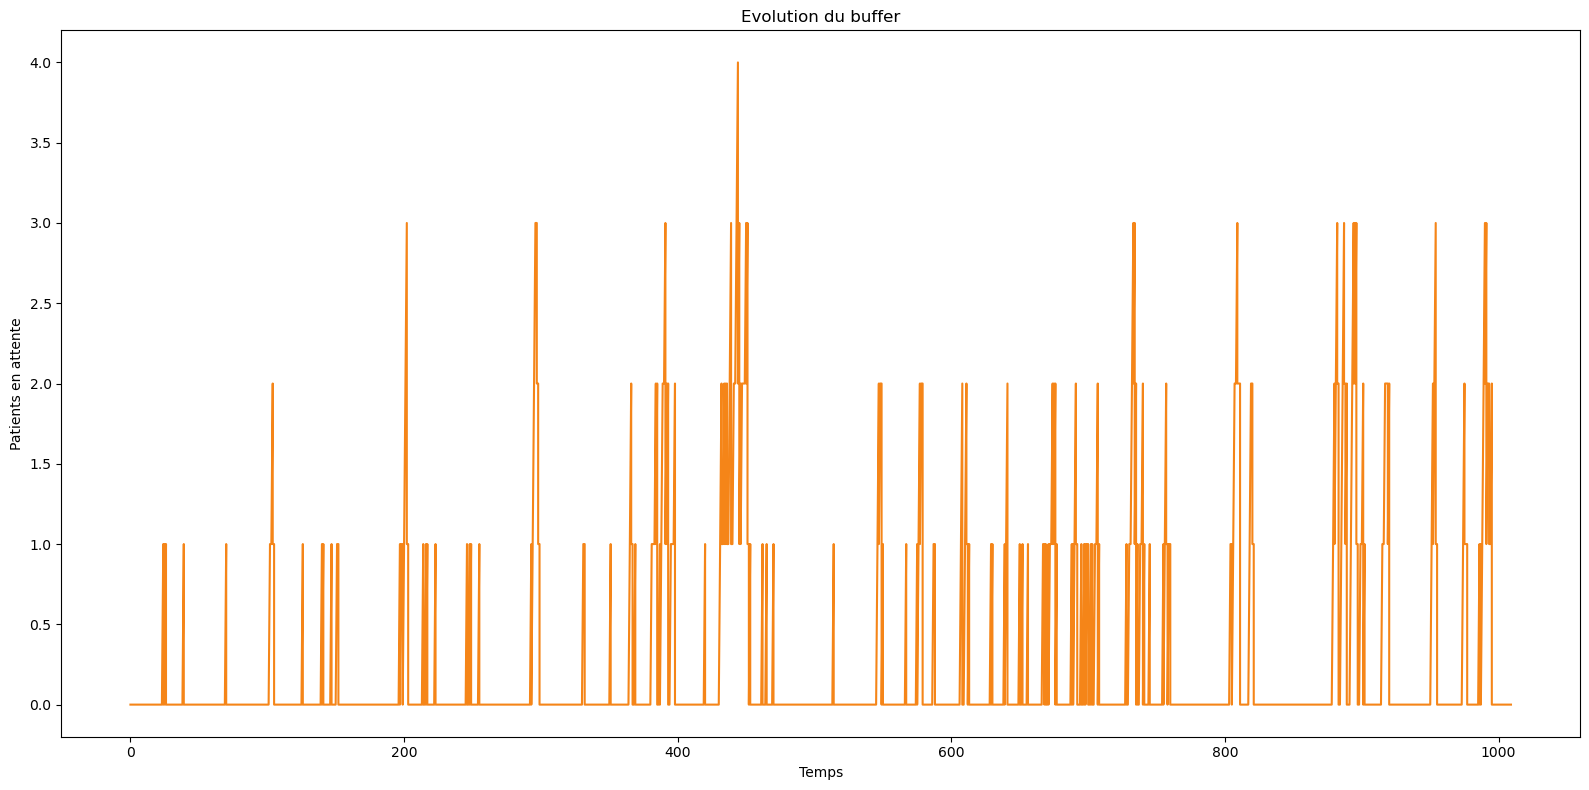

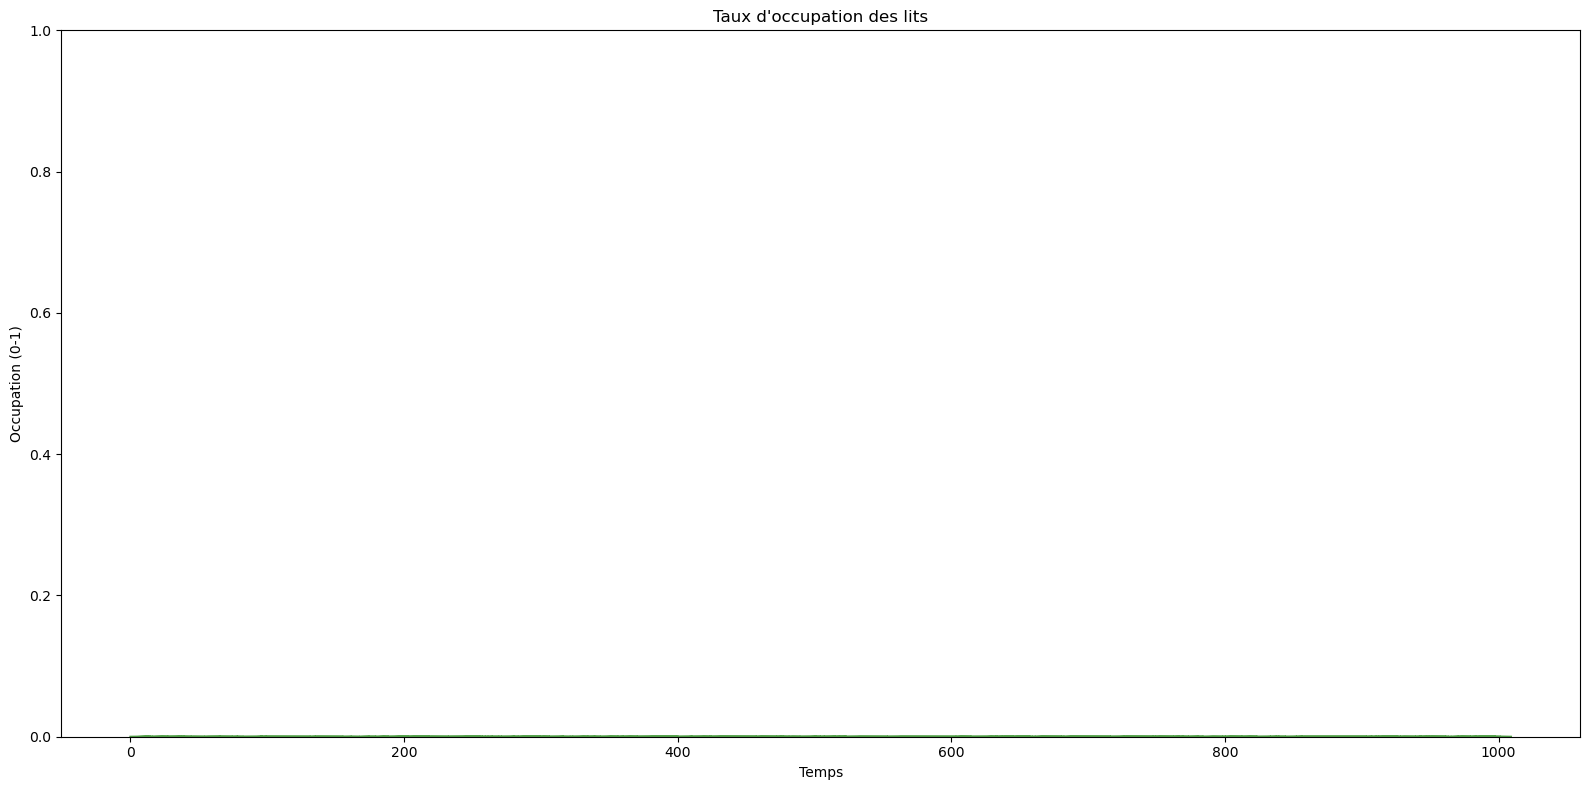

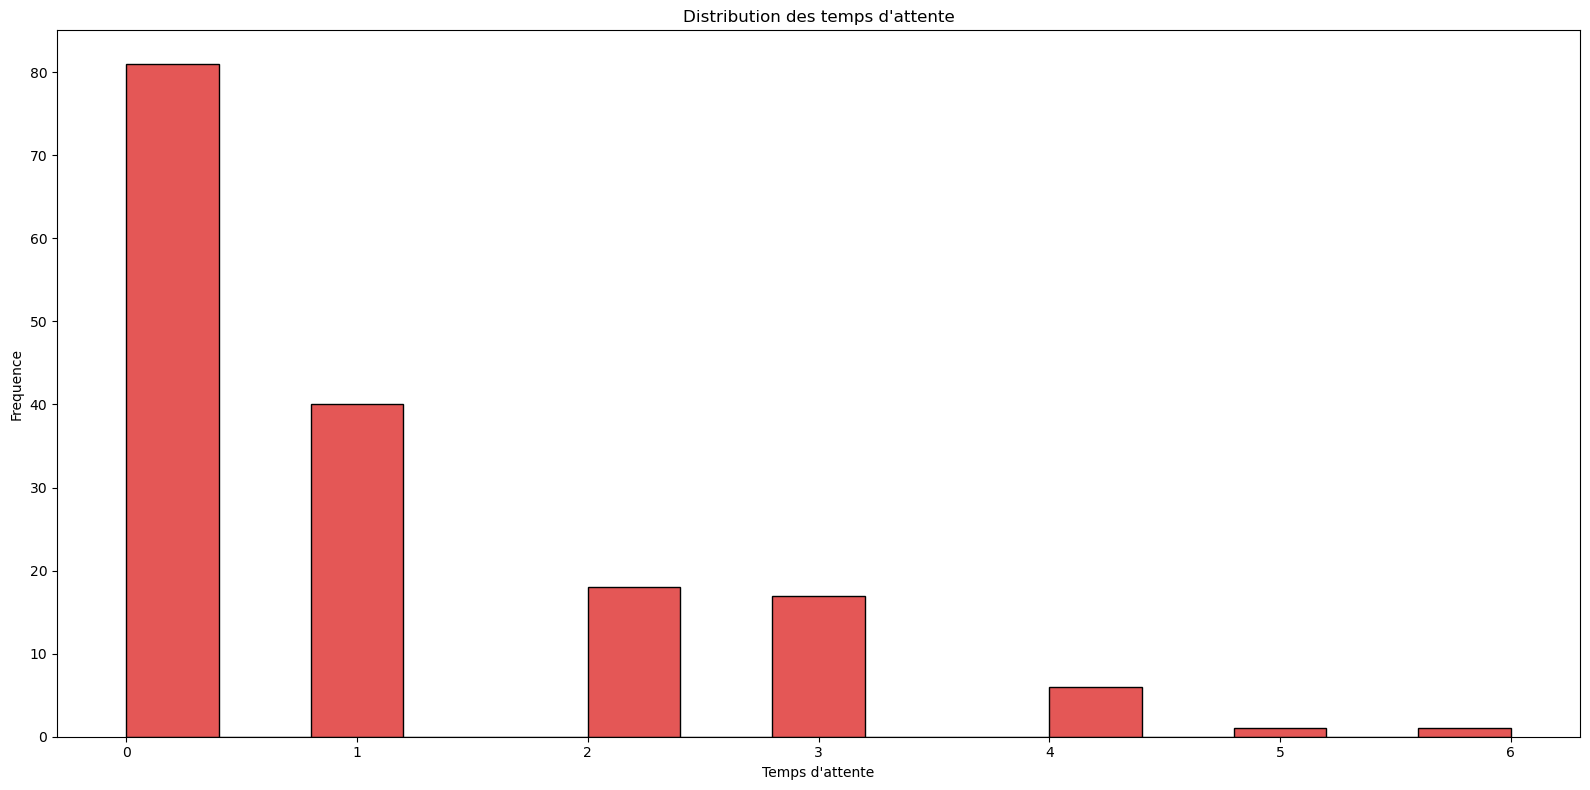

In [14]:
if "patients" not in globals() or "hospitals" not in globals() or "model" not in globals():
    raise ValueError("Execute d'abord les sections chargement + dataset + entrainement avant la simulation.")

stats = run_operational_simulation(patients, hospitals, model)

total = len(patients)
allocated_total = stats["allocated_immediately"] + stats["reallocated_from_buffer"]

allocation_rate = allocated_total / total if total else 0
initial_buffer_rate = stats["buffered"] / total if total else 0
critical_buffer_rate = stats["critical_buffered"] / total if total else 0
mean_wait = np.mean(stats["waiting_times"]) if stats["waiting_times"] else 0

print("Taux d'allocation final :", round(allocation_rate, 4))
print("Taux de mise en buffer initiale :", round(initial_buffer_rate, 4))
print("Patients critiques initialement bufferises :", round(critical_buffer_rate, 4))
print("Nombre de reinjections reussies :", stats["reallocated_from_buffer"])
print("Temps d'attente moyen (unites temporelles) :", round(float(mean_wait), 2))

# ---------- Graphiques (1 par figure) ----------
timeline_df = pd.DataFrame(stats["timeline"])
alloc_df = pd.DataFrame(
    [{"hospital": k, "allocated_patients": v} for k, v in stats["by_hospital"].items()]
).sort_values("allocated_patients", ascending=False)

# 1) Allocations par hopital
plt.figure(figsize=(16, 8))
if not alloc_df.empty:
    plt.bar(alloc_df["hospital"], alloc_df["allocated_patients"], color="#4C78A8")
plt.title("Allocations par hopital")
plt.xlabel("Hopital")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# 2) Evolution du buffer
plt.figure(figsize=(16, 8))
if not timeline_df.empty:
    plt.plot(timeline_df["time"], timeline_df["buffer_size"], color="#F58518")
plt.title("Evolution du buffer")
plt.xlabel("Temps")
plt.ylabel("Patients en attente")
plt.tight_layout()
plt.show()

# 3) Taux d'occupation des lits
plt.figure(figsize=(16, 8))
if not timeline_df.empty:
    plt.plot(timeline_df["time"], timeline_df["bed_occupancy"], color="#54A24B")
plt.title("Taux d'occupation des lits")
plt.xlabel("Temps")
plt.ylabel("Occupation (0-1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 4) Distribution des temps d'attente
plt.figure(figsize=(16, 8))
if stats["waiting_times"]:
    plt.hist(stats["waiting_times"], bins=15, color="#E45756", edgecolor="black")
else:
    plt.text(0.5, 0.5, "Aucun patient n'a attendu", ha="center", va="center")
plt.title("Distribution des temps d'attente")
plt.xlabel("Temps d'attente")
plt.ylabel("Frequence")
plt.tight_layout()
plt.show()